# Ensemble

Autor: Bartosz Perz

## Zadanie 1: Salud 2030

Na potrzeby zadania potraktuj dane jako w pełni zebrane od ankietowanych.

### Wprowadzenie

Pracujesz jako Senior Data Scientist w **Secretaría de Salud de México** – meksykańskim Ministerstwie Zdrowia. Rząd Meksyku przeznaczył ogromne fundusze, angażując Cię do pomocy w wywiązaniu się z globalnych zobowiązań wobec ONZ i WHO.

Meksyk, jako sygnatariusz Agendy 2030, kładzie szczególny nacisk na **3. Cel Zrównoważonego Rozwoju (SDG 3): Dobre zdrowie i jakość życia**. Kluczowym elementem tego celu jest **Zadanie 3.4**, które zakłada ograniczenie do 2030 roku o jedną trzecią przedwczesnej umieralności z powodu chorób niezakaźnych (NCDs) poprzez zapobieganie i leczenie.

Jak jednak spełnić to wymaganie? Bierzesz na celownik otyłość – główny czynnik ryzyka wystąpienia chorób układu krążenia, cukrzycy typu 2 i nadciśnienia, które stanowią trzon problemów zdrowotnych wymienionych w SDG 3. Twoim celem jest stworzenie modelu, który na podstawie danych ankietowych zidentyfikuje osoby wymagające interwencji profilaktycznej. Aby pozyskać zbiór danych do uczenia modeli, w wybranych przychodniach przeprowadzono badanie pilotażowe.

Musisz działać precyzyjnie, ponieważ niedokładny model pominie zagrożonych pacjentów, a model zbyt "ciężki" obliczeniowo nie będzie mógł zostać wdrożony w wiejskich przychodniach o ograniczonych zasobach. W Meksyku, gdzie wskaźniki otyłości należą do najwyższych na świecie, Twoja praca nad optymalnym modelem predykcyjnym jest bezpośrednim wkładem w walkę o wydłużenie życia obywateli i redukcję obciążenia systemu ochrony zdrowia.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych dot. otyłości (UCI ID: 544)](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition).
2. **Wyucz modele klasyfikacyjne**. Wykorzystaj bibliotekę `scikit-learn` i zbadaj:

* **Pojedyncze drzewa decyzyjne** i **regresję logistyczną** – jako bazowe modele, łatwe do interpretacji przez lekarza.
* **Bagging:** `BaggingClassifier` z płytkimi drzewami, głębokimi drzewami oraz z regresją logistyczną. Przetestuj wpływ parametrów *n_estimators*, *bootstrap* i *bootstrap_features* na wyniki.
* **Boosting:** `AdaBoost` (przetestuj na płytkich drzewach i regresji logistycznej) oraz `GradientBoosting` (oparty domyślnie na drzewach). Zbadaj relację (trade-off) między parametrami *n_estimators* i *learning_rate*.
* **Stacking & Voting:** skonstruuj kolejny komitet wg własnego uznania (dobierz parametry i modele). Połącz modele o różnej architekturze, by sprawdzić, czy zespół różnych algorytmów daje lepsze efekty niż pojedynczy "ekspert".

3. **Zwaliduj modele** pod kątem wdrożenia krajowego.

* Dobierz miary **skuteczności** modelu adekwatne do problemu.
* Zwróć uwagę na **czas predykcji**.
* Zbadaj **pewność (confidence) modelu**.

4. **Zapisz wnioski dla Ministerstwa Zdrowia.**

Przy realizacji poleceń pamiętaj o charakterze zadania. Który z modeli zarekomendowałbyś do wdrożenia? Czy dokładność modelu jest jedynym wyznacznikiem jego jakości? Czy są modele, których wdrożenie byłoby stratą zasobów publicznych?

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
path = '/content/drive/MyDrive/datasets/ObesityDataSet_raw_and_data_sinthetic.csv'
df = pd.read_csv(path)
df.shape


Mounted at /content/drive


(2111, 17)

### Walidacja danych


- Sprawdzenie braków

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [36]:
assert sum(df.isnull().sum()) == 0

- Nie występują braki


In [37]:
if df.duplicated().sum() != 0:
    df.drop_duplicates(inplace=True)
assert df.duplicated().sum() == 0

- Usunięto duplikaty


| Skrót zmiennej | Pełna nazwa (ang.) | Opis (pl) | Typ danych (przed mapowaniem) |
| :--- | :--- | :--- | :--- |
| **Gender** | Gender | Płeć pacjenta. | Kategoryczny (Female / Male) |
| **Age** | Age | Wiek w latach. | Numeryczny (Ciągły) |
| **Height** | Height | Wzrost w metrach. | Numeryczny (Ciągły) |
| **Weight** | Weight | Waga w kilogramach. | Numeryczny (Ciągły) |
| **family_history_with_overweight** | Family History with Overweight | Czy w najbliższej rodzinie występowały problemy z otyłością? | Kategoryczny (yes / no) |
| **FAVC** | Frequent consumption of high caloric food | Czy pacjent często spożywa wysokokaloryczne jedzenie (fast-food)? | Kategoryczny (yes / no) |
| **FCVC** | Frequency of consumption of vegetables | Częstotliwość spożywania warzyw w głównych posiłkach (od 1 do 3). | Numeryczny |
| **NCP** | Number of main meals | Liczba głównych posiłków zjadanych w ciągu dnia (od 1 do 4). | Numeryczny |
| **CAEC** | Consumption of food between meals | Częstotliwość podjadania między głównymi posiłkami. | Kategoryczny (no, Sometimes, Frequently, Always) |
| **SMOKE** | Smoke | Czy pacjent pali papierosy? | Kategoryczny (yes / no) |
| **CH2O** | Consumption of water daily | Ilość wypijanej wody dziennie (od 1 do 3 litrów). | Numeryczny |
| **SCC** | Calories consumption monitoring | Czy pacjent celowo monitoruje spożycie swoich kalorii? | Kategoryczny (yes / no) |
| **FAF** | Physical activity frequency | Częstotliwość aktywności fizycznej w ciągu tygodnia (od 0 do 3). | Numeryczny |
| **TUE** | Time using technology devices | Czas spędzany przed ekranem (telefon, TV, PC) dziennie (od 0 do 2). | Numeryczny |
| **CALC** | Consumption of alcohol | Jak często pacjent pije alkohol. | Kategoryczny (no, Sometimes, Frequently, Always) |
| **MTRANS** | Transportation used | Najczęściej używany środek transportu. | Kategoryczny (Automobile, Motorbike, Bike, Public_Transportation, Walking) |
| **NObeyesdad** | Target Variable (Obesity Level) | **ZMIENNA CELU:** Przypisana klasa wagi / otyłości (od niedowagi do otyłości 3. stopnia). | Kategoryczny (7 różnych klas) |


In [38]:
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['family_history_with_overweight'] = df['family_history_with_overweight'].map({'no': 0, 'yes': 1})
df['FAVC'] = df['FAVC'].map({'no': 0, 'yes': 1}) 
df['SMOKE'] = df['SMOKE'].map({'no': 0, 'yes': 1})
df['SCC'] = df['SCC'].map({'no': 0, 'yes': 1})

df['CAEC'] = df['CAEC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
df['CALC'] = df['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})

df = pd.get_dummies(df, columns=['MTRANS'], prefix='MTRANS')

df['NObeyesdad'] = df['NObeyesdad'].map({
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
})


- Zastąpiłem zmienne kategoryczne wartościami 0, 1. Jeżeli chodzi o zmienne, które są sobie pokrewne zastosowałem Ordinal Encoding. W przypadku środków transportu trzeba było użyć One-Hot Encoding, ponieważ jazda rowerem, a chodzenie pieszo nie ma nic ze sobą wspólnego pod kątem uporządkowania danych.

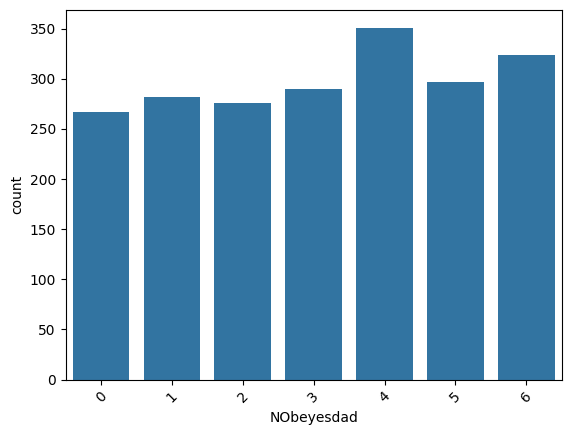

In [41]:
sns.countplot(x='NObeyesdad', data=df)
plt.xticks(rotation=45)
plt.show()

- Zbiór jest zbalansowany pod kątem zmiennej celu, więc nie trzeba używać SMOTE'a. 

### Badanie korelacji

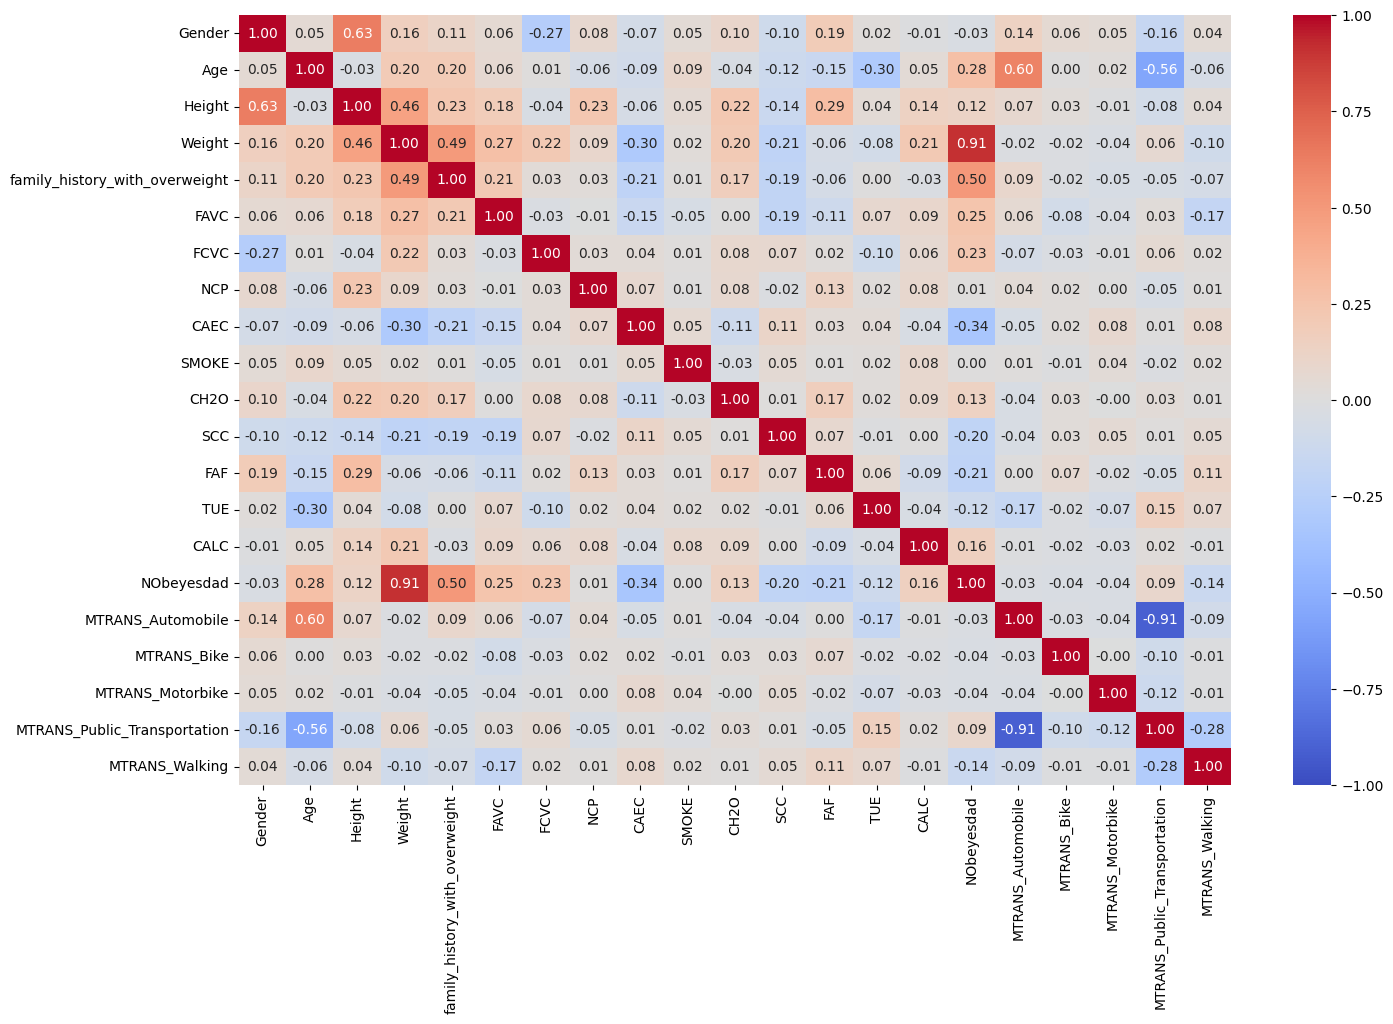

In [40]:
plt.figure(figsize = (16, 10))
sns.heatmap(df.corr(), vmin = -1, vmax = 1 , cmap = "coolwarm", annot = True, fmt= ".2f")
plt.show()

## Zadanie 2: Grzybobranie

### Wprowadzenie

Mieszkasz w "Warszawce". Ostatnio całe miasto opanował nowy trend – grzybobranie! Czy wiedziałeś, że grzybów nie trzeba kupować w sklepie? Rosną w lesie, zupełnie za darmo i E-KO-LO-GICZ-NIE.

Postanawiasz wybrać się do "mało znanego" miejsca – lasu pod Konstancinem-Jeziorną. Niestety, na miejscu okazuje się, że o grzybach nie masz zielonego pojęcia, a odróżnienie borowika od muchomora stanowi dla Ciebie ogromne wyzwanie. Już masz się poddać, ale nagle słyszysz za sobą podniesiony głos:

– Radziu, nie mów do mnie teraz!

Obracasz się i widzisz miło wyglądającą rodzinkę.

<img src="img.jpg" width="400" height="400" />

(Źródło: <a href="https://www.instagram.com/p/COLCA3RHoni/">instagram m_rozenek</a>)

Skądś ich kojarzysz (może z *morning matcha rave*?), ale nie to jest teraz najważniejsze. Widzisz, że próbują rozszyfrować **ZAAWANSOWANY ATLAS GRZYBÓW**. Postanawiasz dołączyć do zadania, ale szybko okazuje się, że rozumiesz z niego tyle co nic. Zamiast zdjęć i opisów, atlas zawiera wyłącznie tabele przedstawiające cechy grzybów. Sprawdzanie całej tabeli w poszukiwaniu odpowiedniego dopasowania do zaobserwowanych parametrów okazu od razu wydaje Ci się marnowaniem czasu. Wykorzystujesz więc wiedzę nabytą na zajęciach ze Sztucznej Inteligencji i postanawiasz stworzyć model uczenia maszynowego klasyfikujący grzyby.

Pamiętaj – błąd algorytmu oznacza poważne zatrucie. Chociaż masz dostęp do potężnych narzędzi, bateria w Twoim telefonie jest na wyczerpaniu, a każda sekunda pracy procesora jest na wagę złota. Musisz zdecydować, jaki model będzie adekwatny do zadania – na tyle precyzyjny, by przeżyć, a zarazem wystarczająco "lekki", by zadziałał w lesie.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych o grzybach (UCI ID: 73)](https://archive.ics.uci.edu/dataset/73/mushroom).
2. Według własnego uznania **wybierz modele** i **wyucz** je. Wykorzystaj zdobytą dotychczas wiedzę. Przynajmniej jednym z testowanych modeli powinien być model zespołowy (ensemble).
3. **Zwaliduj wyuczone modele**. Pamiętaj, że pomyłka może skończyć się zatruciem, więc warto byłoby móc zinterpretować i zrozumieć decyzje modelu.
4. **Zapisz wnioski**.

Przy realizacji poleceń pamiętaj o specyficznym charakterze i ograniczeniach zadania.